In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Clustering: k-means

### Cargar datos

In [2]:
df = pd.read_csv("hyg_sample.csv")
print(df)

        ci  log_lum
0    1.021   1.1288
1    0.614   0.2792
2    1.112   1.4672
3    0.909   1.0468
4    0.580  -3.6920
..     ...      ...
749  1.050   1.2424
750  1.210   1.5828
751  1.378   2.0512
752  1.069   1.7968
753  1.101   0.9260

[754 rows x 2 columns]


### Crear el modelo k-means y entrenarlo con los datos

In [3]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(df)

KMeans(n_clusters=3)

### Obtener asignaciones a clusters y centroides

In [4]:
clusters = kmeans.predict(df)
centroides = kmeans.cluster_centers_

### Graficar el resultado (asignaciones y centroides)

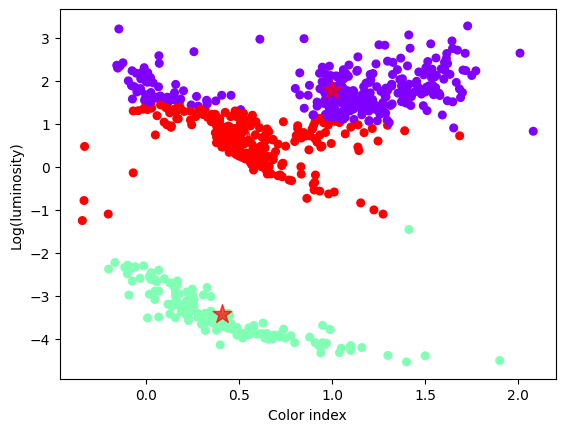

In [11]:
plt.scatter(df["ci"], df["log_lum"], c=clusters, s=30, cmap='rainbow')
plt.scatter(centroides[:, 0], centroides[:, 1], c="red", s=200, alpha=0.7, marker='*')
plt.xlabel('Color index')
plt.ylabel('Log(luminosity)')
plt.show()

### Ahora hacemos análisis de óptimo número de clusters vía elbow method

In [6]:
ks = range(1, 10)
inertias = []
for k in ks:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df)
    inertias.append(kmeans.inertia_)

### Graficamos el resultado (inercia/WCSS vs número de clústers)

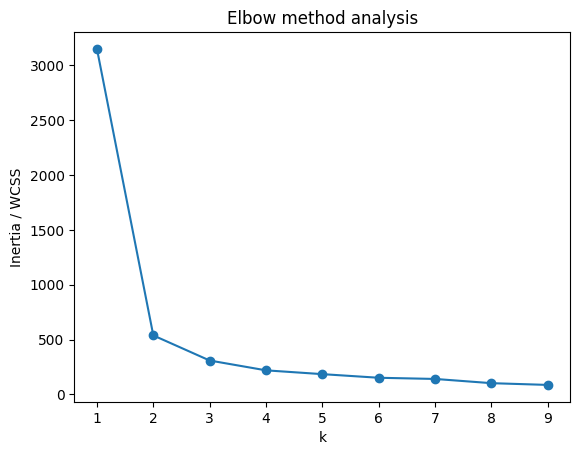

In [8]:
plt.plot(ks, inertias, "o-")
plt.xlabel("k")
plt.ylabel("Inertia / WCSS")
plt.title("Elbow method analysis")
plt.show()

#### -> Podríamos conluir que el codo está en k=2 o en k=3